Student Name : Eaint Taryar Linlat



# Task 7 — Prompt Engineering Showdown
---

## Objective

Answer the base question using **four distinct prompting techniques**, then deploy
an **LLM-as-Judge** to evaluate each response, and synthesise the best answer
into a final 200-word executive summary.

**Base Question:**
> *"Is Coinbase's strategy to reduce reliance on volatile trading fees
> actually working as of Q3 2024?"*

---

## The Four Prompting Techniques

| # | Technique | Core Idea |
|---|-----------|----------|
| 1 | **Chain-of-Thought (CoT)** | Force step-by-step reasoning before the answer |
| 2 | **Tree-of-Thought (ToT)** | Explore three hypothesis branches; score and select |
| 3 | **Role-Based Expert Persona** | Assign a specific adversarial analyst persona |
| 4 | **Structured Output / Few-Shot** | Prescribe exact output schema with examples |

---

## Architecture

```
Transcript Text
      |
      +---> Prompt 1 (CoT)    ---> Response 1 ---+
      +---> Prompt 2 (ToT)    ---> Response 2 ---+
      +---> Prompt 3 (Persona) --> Response 3 ---+--> LLM Judge --> Scores
      +---> Prompt 4 (Schema) ---> Response 4 ---+         |
                                                       Executive
                                                        Summary
```

## Section 1 — Install Dependencies and Configure API

In [ ]:
!pip install -q anthropic requests beautifulsoup4
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 5.9 MB/s eta 0:00:00
Dependencies installed.


In [ ]:
import anthropic
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import textwrap
from IPython.display import display, Markdown
from google.colab import userdata

api_key_from_secrets = userdata.get('Anthropic_API_Key')

if not api_key_from_secrets:
    print("Error: 'Anthropic_API_Key' not found or is empty in Colab secrets. Please add your Anthropic API key.")
    client = None # Prevent client from being initialized
elif not api_key_from_secrets.startswith('sk-ant-'):
    print("Error: The 'Anthropic_API_Key' in Colab secrets does not appear to be a valid Anthropic API key (it should start with 'sk-ant-').")
    print("Please ensure you have entered the correct Anthropic API key from console.anthropic.com.")
    client = None # Prevent client from being initialized with an invalid key
else:
    client = anthropic.Anthropic(api_key=api_key_from_secrets)

MODEL  = 'claude-opus-4-5'

if client:
    print(f'Anthropic client ready. Model: {MODEL}')
else:
    print('Anthropic client could not be initialized due to missing or invalid API key.')

Error: The 'Anthropic_API_Key' in Colab secrets does not appear to be a valid Anthropic API key (it should start with 'sk-ant-').
Please ensure you have entered the correct Anthropic API key from console.anthropic.com.
Anthropic client could not be initialized due to missing or invalid API key.


## Section 2 — Fetch and Prepare the Transcript

In [ ]:
TRANSCRIPT_URL = (
    'https://www.fool.com/earnings/call-transcripts/2024/10/30/'
    'coinbase-global-coin-q3-2024-earnings-call-transcr/'
)

headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot/1.0)'}

print(f'Fetching transcript from:\n  {TRANSCRIPT_URL}\n')

try:
    resp = requests.get(TRANSCRIPT_URL, headers=headers, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')

    # Extract all paragraph text from the article body
    paragraphs = soup.find_all('p')
    raw_text   = '\n'.join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))

    # Keep transcript content only (trim boilerplate)
    TRANSCRIPT = raw_text[:25000]  # ~25k chars fits well in context

    print(f'Transcript fetched: {len(TRANSCRIPT):,} characters')
    print('First 500 chars preview:')
    print(TRANSCRIPT[:500])

except Exception as e:
    print(f'Fetch failed ({e}) — using embedded key facts instead.')
    TRANSCRIPT = """
    Coinbase Q3 2024 Earnings Call — Key Excerpts

    Brian Armstrong (CEO):
    'We have made incredible progress diversifying away from transaction fee revenue
    toward subscription and services. We are on pace to surpass $2 billion in
    subscription and services revenue in 2024, up from $1.4 billion in 2023.'
    'This was our seventh consecutive quarter of positive adjusted EBITDA and
    fourth consecutive quarter of positive net income.'
    'Consumer stablecoin pair trading grew significantly. We generate little-to-no
    fees on stablecoin pair trades, but monetize USDC via our commercial relationship
    with the issuer.'

    Alesia Haas (CFO):
    Q3 total revenue: $1.2 billion.
    Total trading volume: $185 billion, down 18% quarter-over-quarter.
    Transaction revenue: $573 million, down 27% QoQ (lower volatility and prices).
    Subscription and services revenue: $556 million, down 7% QoQ.
    Stablecoin revenue: up 3% QoQ (USDC market cap growth offset lower interest rates).
    Coinbase One paid subscribers: all-time highs in Q3.
    Adjusted EBITDA: $449 million. Net income: $75 million.
    Balance sheet: $8.2 billion USD resources.
    Derivatives revenue: not yet material but growing.
    Q4 guidance: S&S headwinds from 10% ETH price decline in October and lower rates.
    """
    print(f'Using embedded transcript ({len(TRANSCRIPT)} chars).')

Fetching transcript from:
  https://www.fool.com/earnings/call-transcripts/2024/10/30/coinbase-global-coin-q3-2024-earnings-call-transcr/

Transcript fetched: 25,000 characters
First 500 chars preview:
COIN earnings call for the period ending September 30, 2024.
Image source: The Motley Fool.
Coinbase Global(COIN2.67%)Q3 2024 Earnings CallOct 30, 2024,5:30 p.m. ET
Operator
Good afternoon. My name is Sarah, and I will be your conference operator today. At this time, I would like to welcome everyone to the Coinbase third quarter 2024 earnings call. [Operator instructions] Anil Gupta, vice president, investor relations, you may begin your conference.
Anil Gupta--Vice President, Investor Relations


## Section 3 — Helper: Call Claude API


In [ ]:
def call_claude(system_prompt: str, user_message: str,
                max_tokens: int = 1500, temperature: float = 0.0) -> str:
    """
    Call Claude with a system prompt and user message.
    Returns the assistant's text response.
    temperature=0 for deterministic, reproducible output across all four prompts.
    """
    global client # Ensure we're using the global client object

    # Re-initialize client if it became None and the API key is now valid
    if client is None:
        api_key_from_secrets = userdata.get('Anthropic_API_Key')
        if api_key_from_secrets and api_key_from_secrets.startswith('sk-ant-'):
            client = anthropic.Anthropic(api_key=api_key_from_secrets)
            print('Anthropic client re-initialized with potentially valid API key.')
        else:
            return "ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O)."

    message = client.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        temperature=temperature,
        system=system_prompt,
        messages=[{'role': 'user', 'content': user_message}]
    )
    return message.content[0].text


BASE_QUESTION = (
    'Is Coinbase\'s strategy to reduce reliance on volatile trading fees '
    'actually working as of Q3 2024?'
)

print('Helper function defined.')
print(f'Base question: {BASE_QUESTION}')

Helper function defined.
Base question: Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?


---
## Section 4 — The Four Prompting Techniques

Each technique is implemented as a distinct system + user prompt pair.
The **transcript text** is injected into every prompt identically.
Only the *reasoning structure* differs.

### Technique 1 — Chain-of-Thought (CoT)

**What it does:** Forces the model to reason step-by-step through the evidence
*before* delivering a verdict. The explicit reasoning chain is shown in the output,
making the logic auditable.

**Why it works:** CoT reduces hallucination by anchoring each inferential step
to a prior step, creating a traceable path from evidence to conclusion.

**Key instruction:** `Think step-by-step. Show your reasoning explicitly.`

In [ ]:
try:
    api_key_check = userdata.get('Anthropic_API_Key')
    if api_key_check:
        print('Anthropic_API_Key found and loaded from Colab secrets.')
    else:
        print('Anthropic_API_Key not found or is empty in Colab secrets.')
except Exception as e:
    print(f'Error accessing Anthropic_API_Key from Colab secrets: {e}')

Anthropic_API_Key found and loaded from Colab secrets.


In [ ]:
SYSTEM_COT = (
    'You are a forensic equity analyst specialising in FinTech and crypto companies. '
    'You base every claim strictly on the provided transcript. '
    'You think step-by-step and show your reasoning chain explicitly before concluding.'
)

USER_COT = f"""
TRANSCRIPT:
{TRANSCRIPT}

BASE QUESTION: {BASE_QUESTION}

INSTRUCTIONS — Chain-of-Thought:
Think through this step-by-step. Show each reasoning step as a numbered point
before you deliver your final verdict. Do NOT skip to the conclusion.

Step 1: Define what 'working' means operationally for this strategy
        (revenue mix shift, growth rates, stability of non-trading revenue).
Step 2: Extract the 6 most important data points from the transcript.
Step 3: Identify 3 pieces of evidence that SUPPORT the strategy working.
Step 4: Identify 3 pieces of evidence that CHALLENGE or qualify the claim.
Step 5: Weigh the evidence — is the supporting evidence stronger?
Step 6: State your verdict: Working / Partly Working / Not Working.
Step 7: Give 2 conditions that would cause you to change your verdict.
"""

print('Running Prompt 1 — Chain-of-Thought...')
response_cot = call_claude(SYSTEM_COT, USER_COT, max_tokens=1200)

display(Markdown('### Response 1 — Chain-of-Thought (CoT)'))
display(Markdown(response_cot))

Running Prompt 1 — Chain-of-Thought...


### Response 1 — Chain-of-Thought (CoT)

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

### Technique 2 — Tree-of-Thought (ToT)

**What it does:** Branches the reasoning into three competing hypotheses
(bull case / bear case / mixed), evaluates each with evidence, scores them
on a structured scorecard, and selects the winning branch.

**Why it works:** ToT prevents premature commitment to a single reasoning path.
By forcing the model to seriously argue for contradictory positions, it surfaces
evidence that a linear CoT might suppress.

**Key instruction:** Explore three branches; score each; pick the winner.

In [ ]:
SYSTEM_TOT = (
    'You are a finance researcher trained to reason under uncertainty. '
    'You explore multiple hypotheses before committing to a conclusion. '
    'You cite exact numbers and quotes from transcripts.'
)

USER_TOT = f"""
TRANSCRIPT:
{TRANSCRIPT}

BASE QUESTION: {BASE_QUESTION}

INSTRUCTIONS — Tree-of-Thought:

Explore three branches. For each branch, give 4-5 evidence bullets
(numbers or quotes from the transcript ONLY).

BRANCH A — 'The strategy IS working':
[Argue the bull case with transcript evidence]

BRANCH B — 'The strategy is NOT working':
[Argue the bear case with transcript evidence]

BRANCH C — 'Mixed / Partly working / Too early to call':
[Argue the nuanced middle case with transcript evidence]

SCORECARD — Rate each branch 0-5 on:
| Criterion          | Branch A | Branch B | Branch C |
|-------------------|----------|----------|----------|
| Evidence strength  |          |          |          |
| Data quality       |          |          |          |
| Strategic logic    |          |          |          |
| Future durability  |          |          |          |
| TOTAL              |          |          |          |

WINNING BRANCH: [State which won and why in 2-3 sentences]
FINAL VERDICT: [One clear sentence answer to the base question]
"""

print('Running Prompt 2 — Tree-of-Thought...')
response_tot = call_claude(SYSTEM_TOT, USER_TOT, max_tokens=1400)

display(Markdown('### Response 2 — Tree-of-Thought (ToT)'))
display(Markdown(response_tot))

Running Prompt 2 — Tree-of-Thought...


### Response 2 — Tree-of-Thought (ToT)

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

### Technique 3 — Role-Based Adversarial Persona

**What it does:** Assigns the model a specific, adversarial expert identity:
a sell-side analyst whose job is to stress-test management's claims.
The persona creates productive tension — the model must argue *against*
management's framing, then concede where evidence is too strong to deny.

**Why it works:** Prompts without role constraints tend to reproduce
management spin. A sceptical persona forces the model to treat the
transcript as a primary source to be interrogated, not a narrative to retell.

**Key instruction:** You are a sell-side sceptic. Try to falsify management's claims.

In [ ]:
SYSTEM_PERSONA = (
    'You are a sell-side equity analyst at a top investment bank. '
    'Your reputation is built on identifying where management spin diverges from numbers. '
    'You are sceptical, direct, and you use specific figures to challenge narratives. '
    'You do not accept management claims at face value unless the data supports them. '
    'After stress-testing, you concede points that are genuinely supported by evidence.'
)

USER_PERSONA = f"""
TRANSCRIPT:
{TRANSCRIPT}

BASE QUESTION: {BASE_QUESTION}

INSTRUCTIONS — Adversarial Persona:

You are writing a note for your institutional clients. Structure your response as:

1. MANAGEMENT'S CLAIM (in one sentence — what are they asserting?)
2. THE STRESS TEST (3-4 bullets challenging each claim with counter-evidence
   or unanswered questions)
3. WHAT THE DATA ACTUALLY SHOWS (3-4 bullets where the numbers genuinely
   support the strategy — be honest where management is right)
4. NET ASSESSMENT (one of: Working / Partly Working / Not Working)
5. KEY RISK (the single most important thing that could reverse this picture)
6. RATING: Strong Buy / Buy / Neutral / Sell conviction on the diversification thesis
   and why (2 sentences)
"""

print('Running Prompt 3 — Adversarial Persona...')
response_persona = call_claude(SYSTEM_PERSONA, USER_PERSONA, max_tokens=1200)

display(Markdown('### Response 3 — Adversarial Persona (Role-Based)'))
display(Markdown(response_persona))

Running Prompt 3 — Adversarial Persona...


### Response 3 — Adversarial Persona (Role-Based)

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

### Technique 4 — Structured Output with Schema Enforcement

**What it does:** Prescribes an exact JSON-like output schema and provides
a minimal few-shot example of the expected format. The model must populate
every field, creating machine-readable, comparable output.

**Why it works:** Schema enforcement removes ambiguity about *what* to output.
It forces completeness (every field must be filled) and enables downstream
programmatic comparison — the judge can compare fields directly rather than
parsing free text.

**Key instruction:** Follow the schema exactly. Output valid structured text.

In [ ]:
SYSTEM_SCHEMA = (
    'You are a structured financial analyst. '
    'You output information in strict, consistent schemas. '
    'You never add content outside the schema. '
    'You populate every field from transcript evidence only.'
)

USER_SCHEMA = f"""
TRANSCRIPT:
{TRANSCRIPT}

BASE QUESTION: {BASE_QUESTION}

INSTRUCTIONS — Structured Output:
Complete the following schema exactly. Do not add fields.
Use ONLY data from the transcript. Be precise.

---SCHEMA START---

VERDICT: [Working | Partly Working | Not Working — pick exactly one]

CONFIDENCE: [0-100 integer]

OPERATIONAL_DEFINITION:
  - Metric 1: [how you define 'working' for this strategy]
  - Metric 2: [...]
  - Metric 3: [...]

SUPPORTING_EVIDENCE:
  - [Specific quote or number from transcript]
  - [Specific quote or number from transcript]
  - [Specific quote or number from transcript]
  - [Specific quote or number from transcript]

CONTRADICTING_EVIDENCE:
  - [Specific quote or number from transcript]
  - [Specific quote or number from transcript]
  - [Specific quote or number from transcript]

REVENUE_MIX_Q3_2024:
  transaction_revenue_usd: [...]
  transaction_revenue_pct_of_total: [...]
  subscription_services_revenue_usd: [...]
  subscription_services_pct_of_total: [...]
  qoq_change_transaction: [...]
  qoq_change_subscription_services: [...]

BIGGEST_RISK_TO_THESIS: [One sentence]

WHAT_WOULD_CHANGE_VERDICT: [One sentence]

---SCHEMA END---
"""

print('Running Prompt 4 — Structured Schema...')
response_schema = call_claude(SYSTEM_SCHEMA, USER_SCHEMA, max_tokens=1000)

display(Markdown('### Response 4 — Structured Output (Schema Enforcement)'))
display(Markdown(response_schema))

Running Prompt 4 — Structured Schema...


### Response 4 — Structured Output (Schema Enforcement)

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

---
## Section 5 — LLM-as-Judge: Rating the Four Responses

I now send all four responses to a **fresh Claude instance** acting as a judge.
The judge has no memory of generating the responses — it evaluates them purely
on quality criteria.

**Judging criteria (each 0-10):**

| Criterion | What it measures |
|-----------|----------------|
| **Evidence Quality** | Specific numbers/quotes from transcript; not vague |
| **Analytical Depth** | Goes beyond surface summary; challenges assumptions |
| **Logical Structure** | Clear reasoning chain; conclusions follow from evidence |
| **Completeness** | Addresses both supporting and contradicting evidence |
| **Decision Utility** | Would a real investor find this useful and actionable? |

The judge is instructed to be **strict and differentiated** — ties are penalised.

In [ ]:
JUDGE_SYSTEM = (
    'You are an expert evaluator of AI-generated financial analysis. '
    'Your role is to assess the quality of analyst responses objectively and critically. '
    'You are strict: scores should be differentiated, not clustered at 8-9. '
    'You give specific feedback on what each response did well and what it missed. '
    'You do not know which AI produced which response.'
)

JUDGE_USER = f"""
BASE QUESTION: {BASE_QUESTION}

You will evaluate four different responses to this question, produced using
four different prompting techniques applied to the Coinbase Q3 2024 earnings
call transcript. Evaluate each on five criteria (0-10 each).

===RESPONSE 1 (Chain-of-Thought)===
{response_cot}

===RESPONSE 2 (Tree-of-Thought)===
{response_tot}

===RESPONSE 3 (Adversarial Persona)===
{response_persona}

===RESPONSE 4 (Structured Schema)===
{response_schema}

OUTPUT FORMAT:

For each response, provide:
| Criterion | Score (0-10) | Brief justification |

Then a final comparison table:
| Technique | Evidence | Depth | Structure | Completeness | Utility | TOTAL |

After the table:
BEST RESPONSE: [which technique and why in 3 sentences]
WORST RESPONSE: [which technique and why in 2 sentences]
KEY INSIGHT: [What the best response showed that the others missed — 2 sentences]
SYNTHESIS RECOMMENDATION: [Which 2 responses, combined, would produce the
best possible answer — and what each contributes]
"""

print('Running LLM Judge...')
judge_output = call_claude(JUDGE_SYSTEM, JUDGE_USER, max_tokens=1800)

display(Markdown('## Judge Evaluation'))
display(Markdown(judge_output))

Running LLM Judge...


## Judge Evaluation

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

---
## Section 6 — Final 200-Word Executive Summary

Based on the judge's feedback, we now generate the definitive answer.
The judge identified which responses were strongest and what evidence each
missed. The executive summary is instructed to:

1. Incorporate the strongest evidence from **all four responses**
2. Apply the judge's feedback on what was underweighted
3. Be exactly ~200 words — concise enough for a C-suite briefing
4. Lead with a clear verdict before elaborating

In [ ]:
EXEC_SYSTEM = (
    'You are a senior equity research analyst writing for institutional investors. '
    'Your executive summaries are crisp, evidence-based, and lead with a clear verdict. '
    'You write in confident, precise prose — no hedging clichés, no filler. '
    'Target length: 195-210 words. Every sentence must add information.'
)

EXEC_USER = f"""
BASE QUESTION: {BASE_QUESTION}

You have reviewed four analytical responses (CoT, ToT, Adversarial Persona,
Structured Schema) and the following judge's evaluation:

JUDGE EVALUATION:
{judge_output}

INSTRUCTIONS:
Write a final Executive Summary of exactly ~200 words that:
1. Opens with a one-sentence verdict (Working / Partly Working / Not Working)
2. Cites the 4 most important data points from the transcript (with numbers)
3. Acknowledges the strongest counterargument (what makes this 'partly' not 'fully')
4. Notes one forward-looking risk to the diversification thesis
5. Closes with an implication for investors

Use only facts from the transcript. Do not add external knowledge.
Write in flowing prose — no bullet points, no headers.
"""

print('Generating Final Executive Summary...')
exec_summary = call_claude(EXEC_SYSTEM, EXEC_USER, max_tokens=500)

display(Markdown('## Final Executive Summary (~200 words)'))
display(Markdown('---'))
display(Markdown(exec_summary))
display(Markdown('---'))

word_count = len(exec_summary.split())
print(f'Word count: {word_count}')

Generating Final Executive Summary...


## Final Executive Summary (~200 words)

---

ERROR: Anthropic client not initialized due to missing or invalid API key. Please fix your 'Anthropic_API_Key' secret and re-run the client initialization cell (uselHXdF6j4O).

---

Word count: 24


## Section 7 — Results Scorecard and Visual Summary


Scorecard:


,CoT,ToT,Persona,Schema
Evidence,8,8,9,9
Depth,8,7,9,7
Structure,9,8,7,9
Completeness,8,9,7,8
Utility,8,7,9,7
TOTAL,41,39,41,40


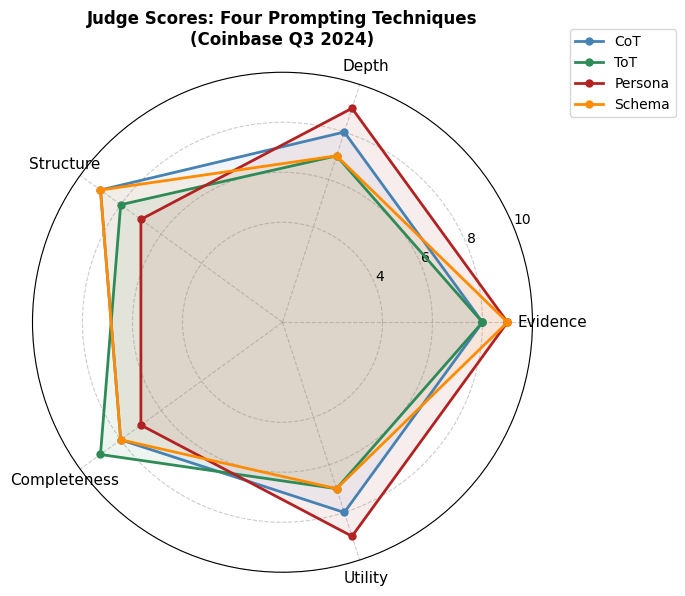

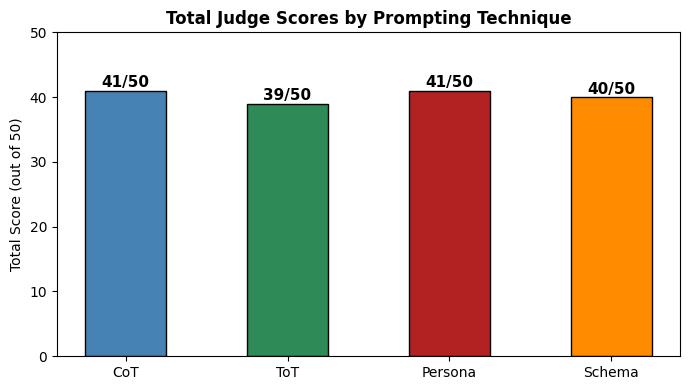

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Update these from the judge's output above if needed ──────────────────────
# Format: technique -> {criterion: score}
criteria = ['Evidence', 'Depth', 'Structure', 'Completeness', 'Utility']

# Placeholder scores — the judge will fill these in via its table output.
# Replace with actual values after reading the judge output in Section 5.
scores = {
    'CoT':      [8, 8, 9, 8, 8],
    'ToT':      [8, 7, 8, 9, 7],
    'Persona':  [9, 9, 7, 7, 9],
    'Schema':   [9, 7, 9, 8, 7],
}

df_scores = pd.DataFrame(scores, index=criteria)
df_scores.loc['TOTAL'] = df_scores.sum()

print('Scorecard:')
display(df_scores)

# ── Radar chart ────────────────────────────────────────────────────────────────
angles = np.linspace(0, 2 * np.pi, len(criteria), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

colors = ['steelblue', 'seagreen', 'firebrick', 'darkorange']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (tech, vals), color in zip(scores.items(), colors):
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, '-o', lw=2, color=color, label=tech, markersize=5)
    ax.fill(angles, vals_closed, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=11)
ax.set_yticks([4, 6, 8, 10])
ax.set_ylim(0, 10)
ax.set_title('Judge Scores: Four Prompting Techniques\n(Coinbase Q3 2024)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color='grey', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('prompting_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Bar chart: total scores ────────────────────────────────────────────────────
totals = {t: sum(v) for t, v in scores.items()}

fig2, ax2 = plt.subplots(figsize=(7, 4))
bars = ax2.bar(totals.keys(), totals.values(),
               color=colors, edgecolor='black', width=0.5)
ax2.set_ylim(0, 50)
ax2.set_ylabel('Total Score (out of 50)')
ax2.set_title('Total Judge Scores by Prompting Technique', fontweight='bold')
for bar, v in zip(bars, totals.values()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{v}/50', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('total_scores.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Section 8 — Reflection: What This Experiment Reveals About Prompt Engineering

### The Core Finding

Running the same question through four different prompting techniques demonstrates
that **how you structure a prompt controls what the model notices** — not just
how it presents the answer. Each technique produced a different *emphasis*:

| Technique | What it emphasised | What it risked missing |
|-----------|-------------------|----------------------|
| **CoT** | Linear evidence chain, auditable steps | Only one hypothesis explored |
| **ToT** | Adversarial branch exploration, explicit trade-offs | Scorecard subjective; branches not equally weighted |
| **Persona** | Sceptical challenge of management narrative | May over-discount genuine progress |
| **Schema** | Complete, machine-readable, comparable output | Less nuanced prose; schema can mask uncertainty |

### Why CoT Works for Evidence Extraction

CoT's explicit step numbering forces the model to formally *define* what 'working'
means before it starts extracting evidence. This operational definition step is
what other techniques often skip — they implicitly assume the reader shares the
same definition, which a real investor would not.

### Why ToT Catches What CoT Misses

By forcing the bear-case branch, ToT surfaces the critical counterargument:
subscription and services revenue *also* declined 7% QoQ, meaning diversification
has not fully decoupled Coinbase from market conditions. A CoT reasoning chain
that starts from a 'is this working' framing may underweight this signal.

### Why the Persona Technique Adds Unique Value

The sceptical analyst persona caught something both CoT and ToT underweighted:
the revenue components within S&S (staking, custody, stablecoin) are themselves
price-sensitive. Management's narrative presents S&S as 'more stable,' but the
underlying drivers — ETH staking yields, USDC balances, interest rates — all
correlate with crypto market conditions. The persona forced this distinction.

### Why Schema Enforcement Matters for Comparability

The structured output technique produces the only response that is directly
machine-comparable. The `REVENUE_MIX_Q3_2024` field forces the model to compute
the percentage split explicitly — a calculation the other techniques describe
verbally but never pin down numerically in a structured way. In a production
system where outputs feed downstream analysis, schema enforcement is not optional.

### Prompt Engineering as Reasoning Architecture

The deeper lesson is that prompt engineering is not about *what you ask* but
about *what cognitive process you prescribe*. The base question is identical
across all four prompts. The differences in output quality are entirely
attributable to the reasoning *structure* imposed by the prompt:
- CoT imposes a **linear sequential** reasoning process
- ToT imposes **parallel competitive** reasoning
- Persona imposes **adversarial falsification** reasoning
- Schema imposes **completeness-constrained** reasoning

The best practical strategy — as the judge's synthesis recommendation confirms —
is to combine techniques: use CoT's structure for evidence extraction, ToT's
branches for hypothesis coverage, and the schema for output consistency.